# Introduction to MICrONS Data Access

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AllenInstitute/connectomics_at_cosyne/blob/main/examples/Cosyne_Data_Access.ipynb)

<b> Electron Microscopy (EM) data enables morphological reconstruction of neurons and detection of their synaptic connectivity </b>. The <a href=https://www.microns-explorer.org/cortical-mm3>MICrONS dataset </a> is one of the largest datasets volume EM datasets currently available, and spans all layers of visual cortex. We will be using this dataset to query the connectivity between neurons in the visual cortex. 
    
<em> Note on data access: </em> To make our lifes easier, we already queried the most of the data needed for this exercise from the database. We have made it available as versioned files that can be read with pandas. The entire dataset is hosted using the <a href=https://caveconnectome.github.io/sections/cave_overview.html> Connectome Annotation Versioning Engine (CAVE) </a>. A separate notebook shows how to use CAVE to generate the files used in this notebook. 

In [1]:
from os.path import join as pjoin
import pandas as pd
import numpy as np

materialization_version = 1718
data_url = "https://github.com/AllenInstitute/connectomics_at_cosyne/raw/refs/heads/main/docs/resources/data"

In [4]:
cell_types_df = pd.read_csv(pjoin(data_url, f'v{materialization_version}_cell_info.csv'))

WIP: Place holder plots showing distribution of proofread cells and column cells

[![](docs/resources/vortex_synapse_plot_square.png)]

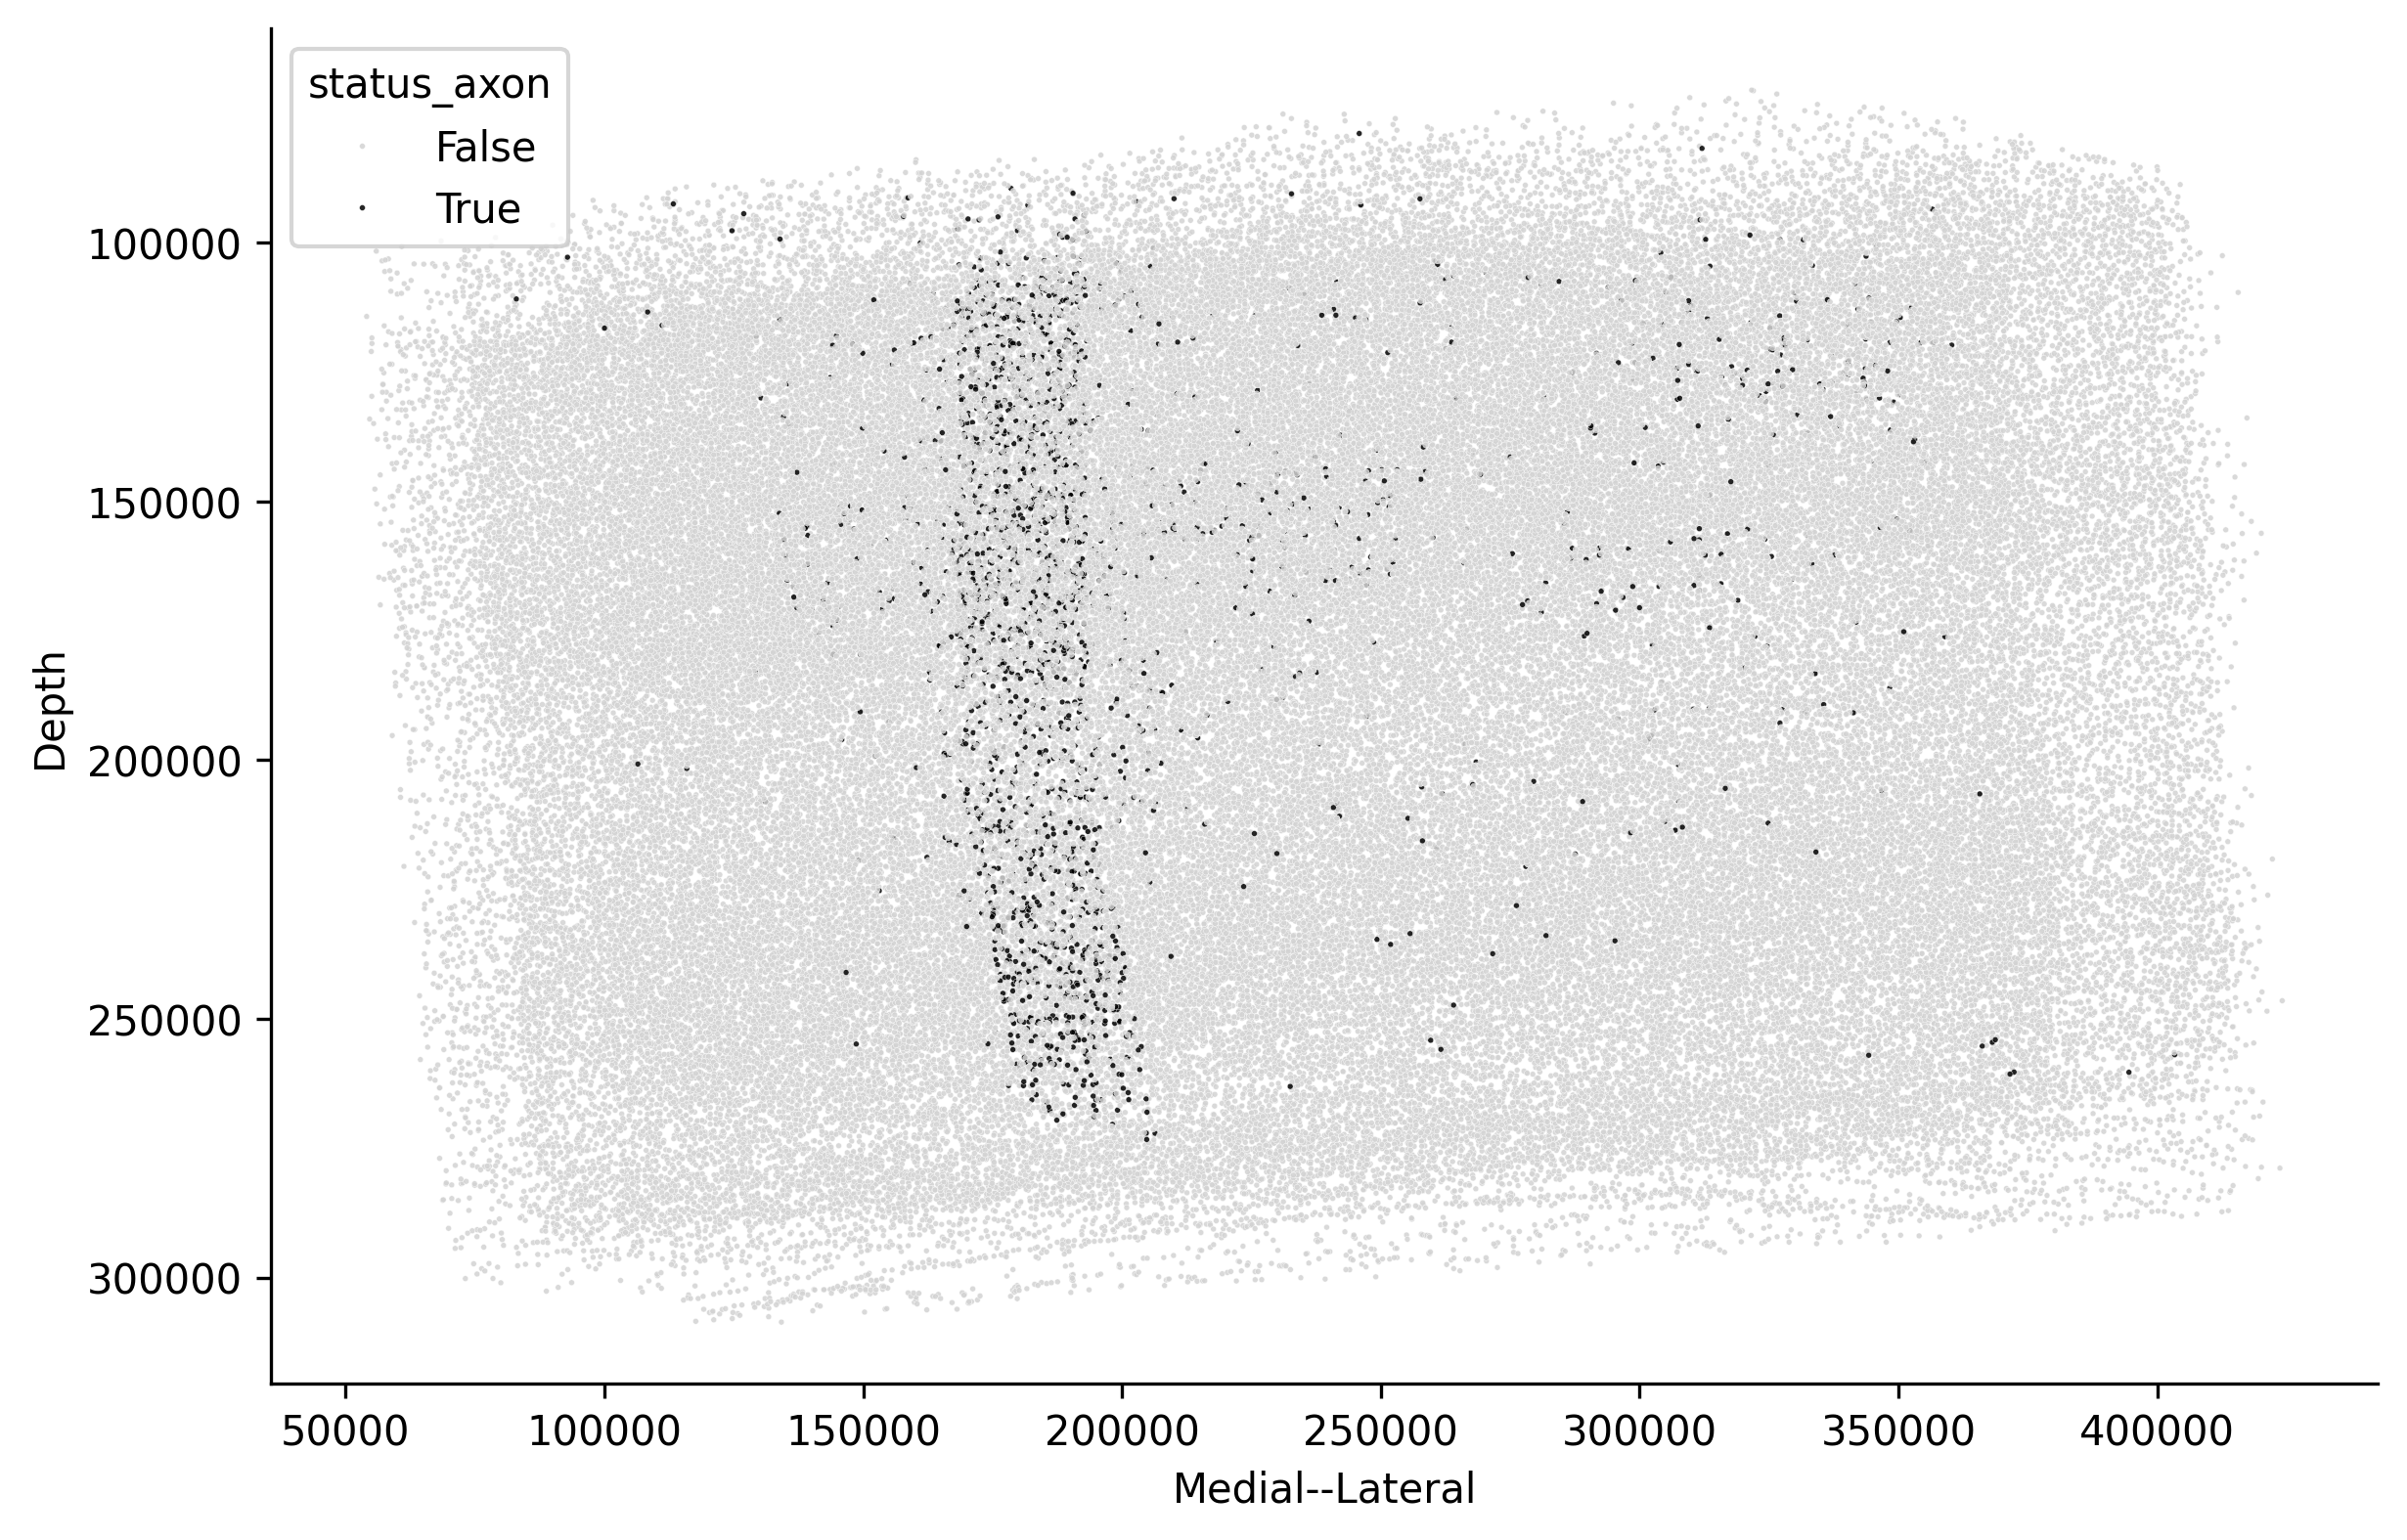

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,1, figsize=(10, 6),dpi=300)
sns.scatterplot(cell_types_df,
                x='pt_position_x',
                y='pt_position_y',
                hue='status_axon',
                hue_order = [False, True], 
                palette={True: 'black', False: 'lightgrey'},
                s=2,
                alpha=0.85,
               )

sns.despine()
ax.invert_yaxis()
ax.set(xlabel='Medial--Lateral', ylabel='Depth')
ax.set_aspect("equal")

## Synapse information

There are <b>337 million synapses</b> in the MICrONS dataset.

We have collected all of the input and output synapses for the proofread cells in version 1300. If you are interested in working with this dataset in the future, we added a notebook that shows how the data was queried.

Note that synapse queries always return the list of every synapse between the neurons in the query, even if there are multiple synapses between the same pair of neurons. A common pattern to generate a list of connections between unique pairs of neurons is to group by the root ids of the presynaptic and postsynaptic neurons and then count the number of synapses between them. 

<b> Here we will load all Proofread-to-Proofread connections within the column, </b> a small subset of the dataset. 

In [15]:
column_synapses = pd.read_feather(pjoin(data_url, f'v{materialization_version}_v1_column_synapses.feather'))
column_synapses.shape

(146711, 6)

## Synapse matrix

The synapses of neurons create a network of synaptic connections. One way of visualizing this connectivity is in a matrix form. Pandas provides the `pivot_table` function that we can use to make a matrix out of the tabular synapse data. For now, we will limit ourselves to the synapses between the proofread neurons.
    
Each synapses has a `size` value assigned to it. How to aggregate the sizes from multiple synapes between two neurons depends on the research question.

In [28]:
# matrix of log-summed synapse size
syn_mat = column_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id", 
                                            values="size", aggfunc=lambda x: np.log10(np.sum(x))).fillna(0)

# Make sure matrix is quadratic
syn_mat = syn_mat.reindex(columns=np.array(syn_mat.index)).astype(float)

row_indices, column_indices = np.nonzero(syn_mat)

Number of edges: 78928
Number of possible edges: 1836025
Fraction of possible edges: 0.0430


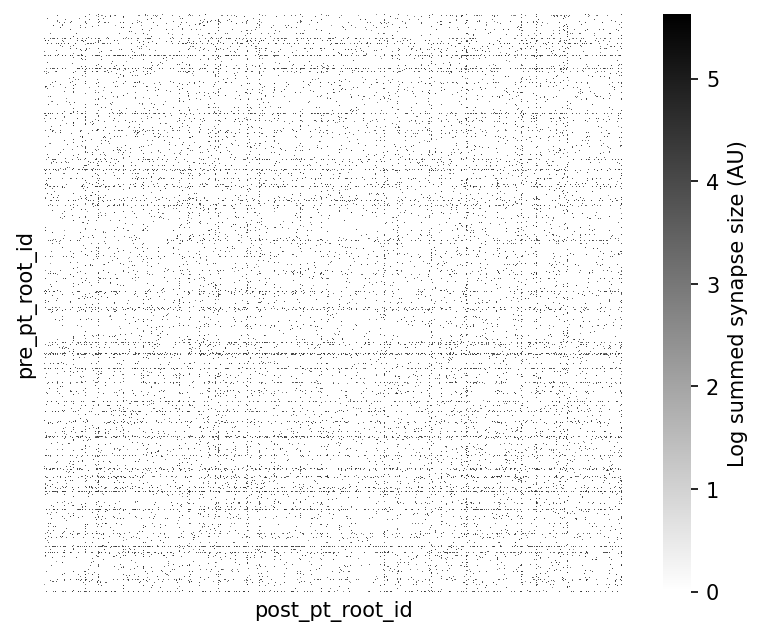

In [29]:
fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
sns.heatmap(syn_mat, cmap="gray_r", xticklabels=[], yticklabels=[], 
            ax=ax, square=True,
            cbar_kws={"label": "Log summed synapse size (AU)"})


n_edges = len(row_indices)
n_possible_edges = syn_mat.shape[0] * syn_mat.shape[1]
print(f"Number of edges: {n_edges}")
print(f"Number of possible edges: {n_possible_edges}")
print(f"Fraction of possible edges: {n_edges / n_possible_edges:.4f}")

Above, we aggregated synapses between the same two neurons by summing their size followed by taken the log. It has been shown that connection strengths are generally log-normally distributed. Below we plot the connection strengths along a logarithmic axis:  

<h4> Consider: different measures of synaptic strength </h4>

When creating a connectivity matrix, how you measure synaptic strength can make a difference in your analysis. For EM data there are 3 common ways of reporting connection strength:

<ol>
    <li> <b> Binary connectivity:</b> whether two cells are connected at all, as shown above.</li>
    <li> <b> Synaptic count:</b> the total number of synapses that are part of the connection. This is typical of the Fly connectome where <code>count</code> captures much of the connection diversity. The modal <code>count</code> in mouse cortex is much lower.</li>
    <li> <b> Synaptic size:</b> the size of the postsynaptic density at every connection, generally aggregated as <code>sum</code> or <code>mean</code> for each unique connection.</li>
    
</ol>
How to take synapse size and number into account depends on the specific analysis. 

The `size` reported in the V1DD dataset measures the synaptic cleft as segmented by the automated classifier in voxels (3d pixels, a measure of volume). These are correlated to anatomical measures such as synaptic area and spine head volumes (for excitatory synapses). 

Let's replot the <b>square matrix</b> with the <code>sum</code> of synapses sizes between each connected pair.

[Text(0.5, 0, 'Sum synapse size (voxels - log scale)'),
 Text(0, 0.5, 'Number of connections')]

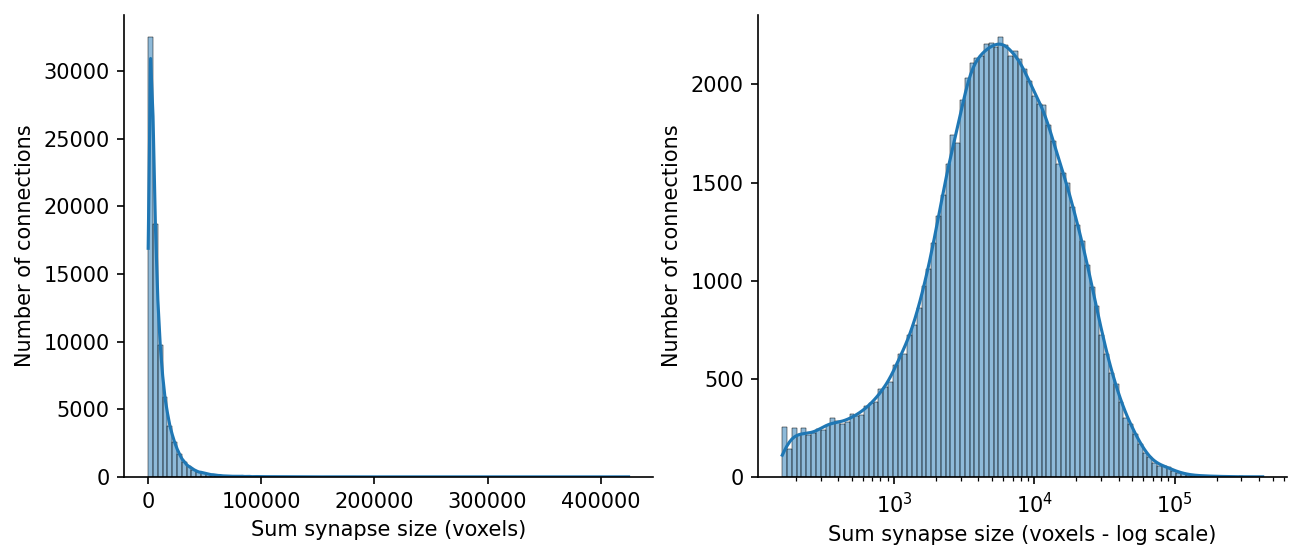

In [35]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

syn_mat = column_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id", 
                                            values="size", aggfunc=lambda x: (np.sum(x))).fillna(0)

# Make sure matrix is quadratic
syn_mat = syn_mat.reindex(columns=np.array(syn_mat.index)).astype(float)

# collect the synaptic weights that are non-zero
edge_weights = syn_mat.to_numpy()[row_indices, column_indices]

# Histogram on linear-x
ax = axs[0]
sns.histplot(
    edge_weights,
    kde=True,
    bins=100,
    ax=ax,
    log_scale=False,
)
ax.spines[["top", "right"]].set_visible(False)
ax.set(xlabel="Sum synapse size (voxels)", ylabel="Number of connections")

# Histogram on log-x
ax = axs[1]
sns.histplot(
    edge_weights,
    kde=True,
    bins=100,
    ax=ax,
    log_scale=True
)
ax.spines[["top", "right"]].set_visible(False)
ax.set(xlabel="Sum synapse size (voxels - log scale)", ylabel="Number of connections")

In other systems than mouse cortex, the number of synapses might be the more important measure (see [Dorkenwald et al., 2022](https://elifesciences.org/articles/76120) for deeper dive into synapse size and counts). 

However, in mouse cortex the modal number of <b>Excitatory-to-excitatory connections is 1</b>.


[Text(0.5, 0, 'Number of synapses per connection'),
 Text(0, 0.5, 'Number of connections')]

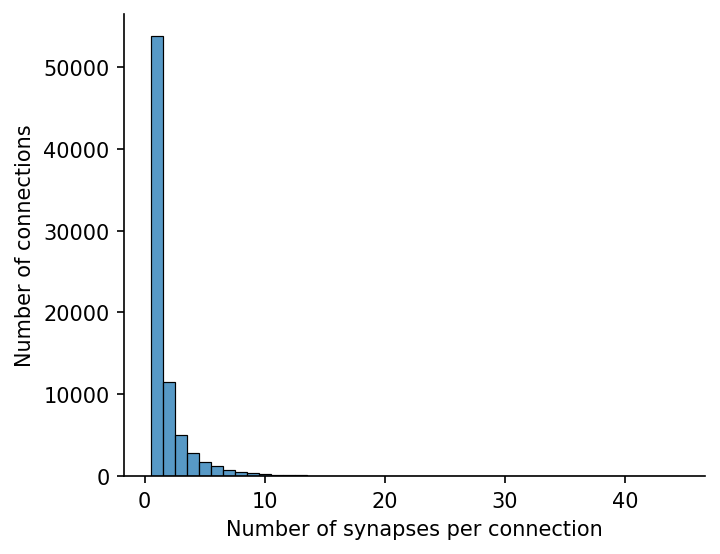

In [37]:
# Histogram on linear-x

syn_mat = column_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id", 
                                            values="size", aggfunc=lambda x: np.sum(x > 0)).fillna(0)

# Make sure matrix is quadratic
syn_mat = syn_mat.reindex(columns=np.array(syn_mat.index)).astype(float)

fig, ax = plt.subplots(figsize=(5, 4), dpi=150)
edge_weights = syn_mat.to_numpy()[row_indices, column_indices]
sns.histplot(
    edge_weights,
    discrete=True,
    ax=ax,
)
ax.spines[["top", "right"]].set_visible(False)
ax.set(xlabel="Number of synapses per connection", ylabel="Number of connections")

## Cell type tables

Identifying the putative ‘cell type’ from the EM morphology is a process that involves both manual and automatic classifications. Subsets of the dataset have been manually classified by anatomists at the Allen Institute, and these ground truth labels used to train and refine different automated ‘feature classifiers’ over time. 

### Using the automated cell types

Many of these automated cell type definitions were established and refined for the [MICrONS Dataset](https://www.microns-explorer.org/) including: 

<ul>
    <li> Perisomatic cell features <a href=https://www.nature.com/articles/s41586-024-07765-7>(Elabbady et al.)</a> </li>
    <li> Morphology and connectivity features <a href=https://www.nature.com/articles/s41586-024-07780-8>(Schneider-Mizell et al.)</a> </li>
</ul>

The process of applying these labels to the V1DD dataset is ongoing, but we will use cell typing from the <code>cell_type_multifeature_combo</code> table which labels cell types according to using soma, nucleus, dendrite, and spine features. These are colated in the `meso_type` column of our cell types dataframe. 

Excitatory neurons are labeled by projection category (IT, ET, NP, CT, and SP for subplate). 

Inhibitory neurons follow labels based on targeting such as ITC (inhibitory targeting), STC (sparsely targeting), PTC (perisomatic targeting), and DTC (dendrite targeting), but might align more with molecular class than exact targeting for a given neuron, particularly among ITC/VIP cells.

*Note:* Cells here without a label will remain black. These are either non-neuronal cells or potential neurons with large segmentation errors that did not pass quality check

In [39]:
cell_types_df.value_counts(['broad_type','meso_type']).sort_index()

broad_type   meso_type  
excitatory   ITC                2
             L1                 1
             L2IT           11820
             L3IT            7599
             L4IT           14584
             L5ET            1737
             L5IT            4892
             L5NP             558
             L6CT           13671
             L6IT            6333
             MC                 2
inhibitory   AltBasket        184
             AltDTC           203
             ChC               29
             DTC              571
             ITC             1276
             ITCperi          188
             L1               356
             L5IT               1
             L6CT               2
             L6IT               1
             MC              1472
             NGC              618
             NMC              284
             PV              3012
peptidergic  peptidergic       63
thalamic     thalamic         261
Name: count, dtype: int64

### Sorting the synapse matrix with cell types
    
Let's combine the synaptic connecitivity with the cell type information. Below we provide logic for sorting a connectivity matrix using a list of labels.  

In [41]:
def sort_matrix_by_types(mat: pd.DataFrame, 
                         labels: pd.DataFrame, 
                         label_type_col: str = "cell_type_auto", 
                         label_id_col: str = "pt_root_id", 
                         post_labels: pd.DataFrame = None, 
                         post_label_type_col: str = None, 
                         post_label_id_col: str = None):
    """Sorts (synapse) matrix by labels.

    This function assumes a square synapse matrix!

    Args:
        mat: synapse matrix as pandas DataFrame
        labels: DataFrame with labels, e.g. the output of client.materialize.query_table('aibs_metamodel_celltypes_v661')
        label_type_col: column name in labels for cell types
        label_id_col: column name in labels for root ids
        post_labels: DataFrame with labels, e.g. the output of client.materialize.query_table('aibs_metamodel_celltypes_v661')
        post_label_type_col: column name in labels for cell types
        post_label_id_col: column name in labels for root ids

    Returns:
        mat_sorted: sorted matrix
        mat_labels: sorted labels; has the same length as matrix
    """
    
    if post_labels is None:
        post_labels = labels
    if post_label_type_col is None:
        post_label_type_col = label_type_col
    if post_label_id_col is None:
        post_label_id_col = label_id_col
        
    mat_sorted = mat.copy()
    
    pre_mat_labels = np.array(labels.set_index(label_id_col).loc[mat_sorted.index][label_type_col])
    pre_sorting = np.argsort(pre_mat_labels)

    post_mat_labels = np.array(post_labels.set_index(post_label_id_col).loc[mat_sorted.T.index][post_label_type_col])
    post_sorting = np.argsort(post_mat_labels)

    mat_sorted = mat_sorted.iloc[pre_sorting].T.iloc[post_sorting].T

    return mat_sorted, pre_mat_labels[pre_sorting], post_mat_labels[post_sorting]

In [57]:
syn_mat = column_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id", 
                                            values="size", aggfunc=lambda x: np.log10(np.sum(x))).fillna(0)


syn_mat = syn_mat.reindex(columns=np.array(syn_mat.index)).astype(float)

# sort the matrix by cell types to render sensibly in heatmap
cell_types_df = cell_types_df.fillna({'cell_type': 'unknown', 'broad_type': 'unknown', 'meso_type': 'unknown'})
syn_mat_ct, syn_mat_cell_types, _ = sort_matrix_by_types(syn_mat, cell_types_df, label_type_col="cell_type")

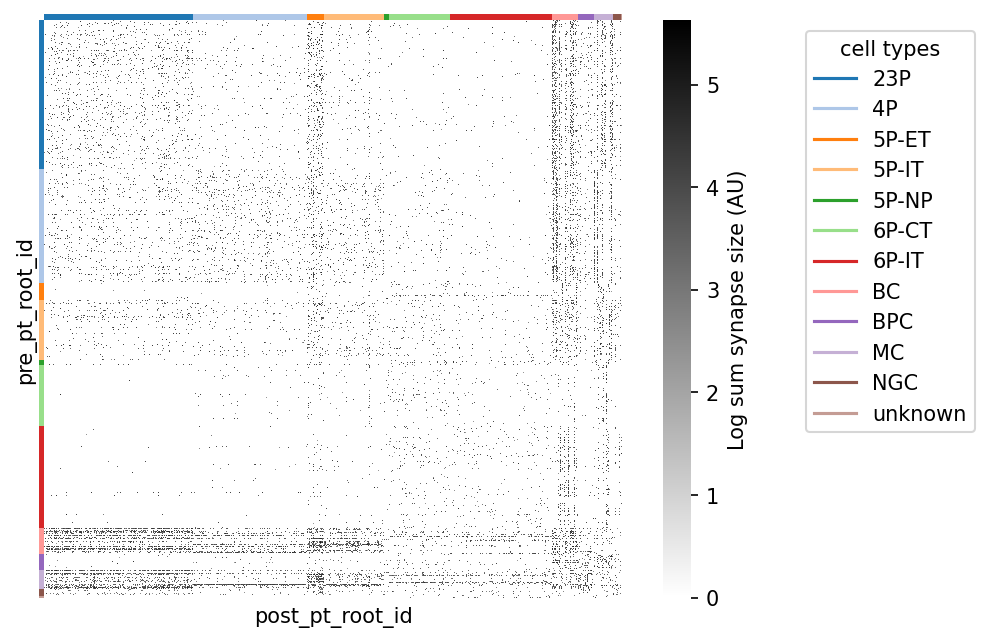

In [58]:
import matplotlib
# add colormap for cell type
cts, ct_idx = np.unique(syn_mat_cell_types, return_inverse=True)
ct_colors = plt.get_cmap("tab20")(ct_idx)

fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
sns.heatmap(syn_mat_ct, cmap="gray_r", xticklabels=[], yticklabels=[], 
            ax=ax, square=True,
            cbar_kws={"label": "Log sum synapse size (AU)"})


# Adding row and column colors for cell types
for i, color in enumerate(ct_colors):
    ax.add_patch(plt.Rectangle(xy=(-0.01, i), width=0.01, height=1, color=color, lw=0,
                               transform=ax.get_yaxis_transform(), clip_on=False))

for i, color in enumerate(ct_colors):
    ax.add_patch(plt.Rectangle(xy=(i, 1), height=0.01, width=1, color=color, lw=0,
                               transform=ax.get_xaxis_transform(), clip_on=False))

# add a legend for the cell types
legend_elements = [matplotlib.lines.Line2D([0], [0], color=plt.get_cmap("tab20")(i), label=ct) for i, ct in enumerate(cts)]
plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.3, 1), title="cell types")
plt.show()

Dig deeper, additional context
1. CAVE access (microns, v1dd, flywire, fafb, h01, etc)
2. ossify for skeleton download
3. plot outputs from a proofread cell
4. plot inputs to proofread cell
5. filter by connections to known neurons; asymmetry of the data
6. post synaptic struture: onto spine, shaft, soma
7. inference of connectivity by cell type (cite ben's paper)
8. branch topology of synapses, colored by distance to soma

Beyond connectivity
1. non neuronal cells
2. interactions at synapses
3. organelle segmentation

# CAVE account setup 

<p>In order to manage server traffic, every user needs to create a CAVE account and download a user token to access CAVE's services programmatically. The CAVE infrastructure can be read about in <a href='https://www.nature.com/articles/s41592-024-02426-z'>more detail in the CAVE Paper</a>. 
    
<p>The MICrONS data is publicly available which means that no extra permissions need to be given to a new user account to access the data. Bulk downloads of some static data are also available without an account on <a href='https://microns-explorer.org/'> MICrONs Explorer</a>.

<b> A Google account (or Google-enabled account) is required to create a CAVE account.

<p> Go to: <a href=https://global.daf-apis.com/auth/api/v1/user/token> https://global.daf-apis.com/auth/api/v1/user/token </a>to view a list of your existing tokens
<p> If you have never made a token before: 
<ol>
  <li>go here: <a href=https://minnie.microns-daf.com/materialize/views/datastack/minnie65_public>https://minnie.microns-daf.com/materialize/views/datastack/minnie65_public</a> to accept terms of service</li>
  <li>then go here <a href=https://global.daf-apis.com/auth/api/v1/create_token> https://global.daf-apis.com/auth/api/v1/create_token</a> to create a new token.</li>
</ol>

In [ ]:
%%capture
!uv pip install caveclient

In [ ]:
import caveclient

my_token = "PASTE_TOKEN_HERE"
client = caveclient.CAVEclient("minnie65_public", auth_token=my_token)

### Setup a persisent token for CAVE authentication
   
<p>If you are running this on your local machine rather than colab, you may also store the token on your machine. This makes future access easier as you do not have to specify the token.

```
client.auth.save_token(token=my_token, overwrite=True)
```